# Self-Reflection RAG

## Definition

**Self-Reflection RAG (Retrieval-Augmented Generation)** is an AI technique in which a language model retrieves relevant information, generates an answer, and evaluates its own response. Based on this evaluation, the model can refine the answer to improve its accuracy, relevance, completeness, and consistency.

## How It Works

1. The user submits a question.
2. The system retrieves relevant documents from a knowledge base.
3. The language model generates an initial answer.
4. The model reviews the answer for:
   - Factual errors
   - Missing information
   - Unsupported claims
   - Irrelevant content
5. The model revises the answer using the retrieved context.
6. The improved answer is returned to the user.

## Benefits

- Improves answer accuracy
- Reduces hallucinations
- Detects missing or unsupported information
- Produces more complete and relevant responses
- Verifies answers against retrieved documents

## Simple Example

### Question

What are the benefits of solar energy?

### Retrieved Context

Solar energy is renewable, reduces electricity costs, and produces no direct greenhouse-gas emissions.

### Initial Answer

Solar energy is useful because it is renewable and inexpensive.

### Self-Reflection

The answer is correct but does not mention its environmental benefit.

### Final Answer

Solar energy is beneficial because it is renewable, can reduce electricity costs, and produces no direct greenhouse-gas emissions.

## Summary

Self-Reflection RAG combines **document retrieval**, **answer generation**, and **self-evaluation**. The reflection step enables the system to identify weaknesses in its initial response and produce a more reliable final answer.

In [1]:
import os
from typing import List
from pydantic import BaseModel
from dotenv import load_dotenv
from langchain.chat_models import init_chat_model
from langchain_community.document_loaders import WebBaseLoader, TextLoader
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document

/var/folders/6c/rlq9mq415gbd8q7dxvzdt3zr0000gn/T/ipykernel_37045/1696332995.py:6: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader, TextLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [3]:
##Laod Environment
load_dotenv()

## set up the environment
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

## Initiate model
llm=init_chat_model("openai:gpt-4o")

In [4]:
## Step 1 - Vectorstore
urls = [
    "https://lilianweng.github.io/posts/2026-07-04-harness/",
    "https://lilianweng.github.io/posts/2024-11-28-reward-hacking/"
]

loaders = [WebBaseLoader(url) for url in urls]
docs=[]
for loader in loaders:
    docs.extend(loader.load())
textSpliters = RecursiveCharacterTextSplitter(separators=["", " ", "\n", "\n\n]"], chunk_size=200, chunk_overlap=50, length_function=len)
chunk = textSpliters.split_documents(docs)
embeddings = OpenAIEmbeddings()
vectorStore = FAISS.from_documents(chunk, embeddings)
retriever_faiss = vectorStore.as_retriever()

In [5]:
## Step 2 - Defining Langgraph State

class SelfReflectionState(BaseModel):
    question: str
    retrieved_docs: List[Document] = []
    answer: str = ""
    reflection: str = ""
    revised: bool = False
    attempts: int = 0

In [ ]:
## Step 3 - Nodes creation

# a. Retrieve Node
def retrieve_docs(state: SelfReflectionState) -> SelfReflectionState:
    docs = retriever_faiss.invoke(state.question)

    return state.model_copy(update={"retrieved_docs": docs})

# b. Generate Answer Node
def generate_answer(state: SelfReflectionState) -> SelfReflectionState:
    context = "\n\n".join([doc.page_content for doc in state.retrieved_docs])
    prompt = f"""
    Use the following context to answer the question:

    Context:
    {context}

    Question:
    {state.question}
    """

    answer = llm.invoke(prompt).content.strip()
    return state.model_copy(update={"answer": answer, "attempts": state.attempts + 1})

# c. Self-Reflect
def reflect_on_answer(state: SelfReflectionState) -> SelfReflectionState:
    prompt = f"""
    Reflect on the following answer to see if it fully address the question.
    state YES if it is a complete and correct, or NO with an explanation.

    Question:
    {state.question}

    Answer:
    {state.answer}

    Respond like:
    Reflection: YES or NO
    Explanation: ...
    """

    result = llm.invoke(prompt).content
    is_revised = "reflection: no" in result.lower()
    return state.model_copy(update={"reflection": result, "revised": is_revised})


In [8]:
# d. Finalizer
def finalize(state: SelfReflectionState) -> SelfReflectionState:
    return state

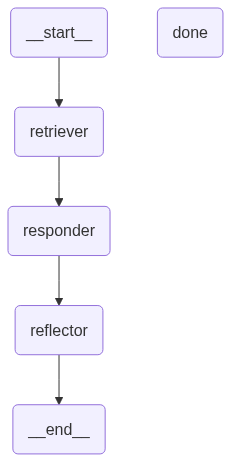

In [10]:
## Step 4 - Building Langgraph Graph

from langgraph.graph import END, START, StateGraph


builder=StateGraph(SelfReflectionState)

builder.add_node("retriever", retrieve_docs)
builder.add_node("responder", generate_answer)
builder.add_node("reflector", reflect_on_answer)
builder.add_node("done", finalize)

# =========
# builder.add_edge(START, "planner")
# == OR ===
builder.set_entry_point("retriever")
# =========
builder.add_edge("retriever", "responder")
builder.add_edge("responder", "reflector")

builder.add_conditional_edges(
    "reflector",
    lambda s: "done" if not s.revised or s.attempts >= 2 else "retriever"
)
builder.add_edge("done", END)

graph = builder.compile()
graph

In [13]:
## Step 5 - Run the Agent

if __name__ == "__main__":
    query = "How File System as Persistent Memory work?"
    state = SelfReflectionState(question=query)
    final_result = graph.invoke(state)

    print("\n No of Attempts:", final_result["attempts"])
    print("\n Reflection Log:", final_result["reflection"])
    print("\n Final Answer:", final_result["answer"])


 No of Attempts: 2

 Reflection Log: Reflection: NO  
Explanation: The provided answer does not fully address how File System as Persistent Memory works. While it mentions the use of the file system for managing complex states and artifacts, it does not explain the technical specifics of how persistent memory is implemented and functions. The answer is lacking details about the relationship between the file system and non-volatile memory technologies (such as NVDIMM or Intel Optane DC Persistent Memory) that allow for the direct byte-addressable memory which maintains data integrity across reboots or crashes. It also omits information about how this system differs from traditional file systems, the mechanism of memory-mapped files, or the way persistent memory offers lower latency compared to disk-based storage, fundamental aspects for understanding how the file system serves as persistent memory.

 Final Answer: The concept of "File System as Persistent Memory" involves using the fil